In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ai-impact-jobs-layoff-risk-dataset.csv')
df.head()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64


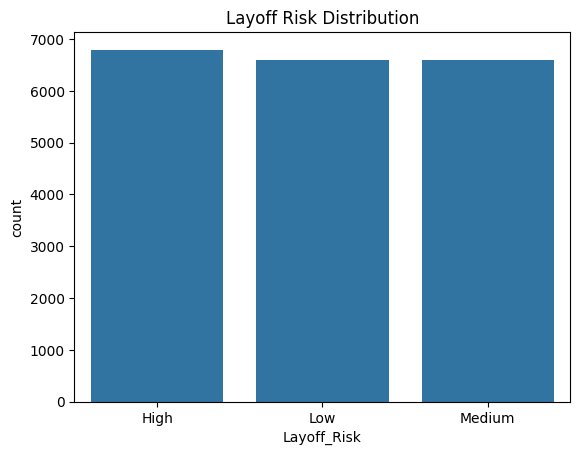

In [ ]:
# Check for nulls
print(df.isnull().sum())

# Plot target distribution
sns.countplot(x='Layoff_Risk', data=df)
plt.title('Layoff Risk Distribution')
plt.show()

In [ ]:
print("--- DATA QUALITY CHECK ---")

# 1. Check for exact duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# If there are duplicates, this line removes them automatically:
df = df.drop_duplicates()

# 2. Check for impossible numbers using .describe()
# Look at the 'min' and 'max' rows for Age, Percentages, etc.
print("\n--- Summary Statistics (Check for weird max/min values) ---")
print(df[['Age', 'Years_of_Experience', 'Tasks_Automated_Percentage']].describe())

# 3. Check for hidden typos in text columns
# (e.g., making sure there isn't "IT" and " I.T. ")
print("\n--- Unique Values in Key Text Columns ---")
# The original 'Industry' and 'Education_Level' columns have been converted to dummy variables.
# These checks should ideally run *before* `pd.get_dummies` is applied.
# print("Industries:", df['Industry'].unique())
# print("Education:", df['Education_Level'].unique())

--- DATA QUALITY CHECK ---
Number of duplicate rows: 0

--- Summary Statistics (Check for weird max/min values) ---
                Age  Years_of_Experience  Tasks_Automated_Percentage
count  20000.000000         20000.000000                 20000.00000
mean      40.361500             7.265500                    37.22895
std       11.526333             4.720606                    19.99512
min       21.000000             0.000000                     4.00000
25%       30.000000             4.000000                    21.00000
50%       40.000000             7.000000                    35.00000
75%       50.000000            11.000000                    51.00000
max       60.000000            32.000000                    93.00000

--- Unique Values in Key Text Columns ---


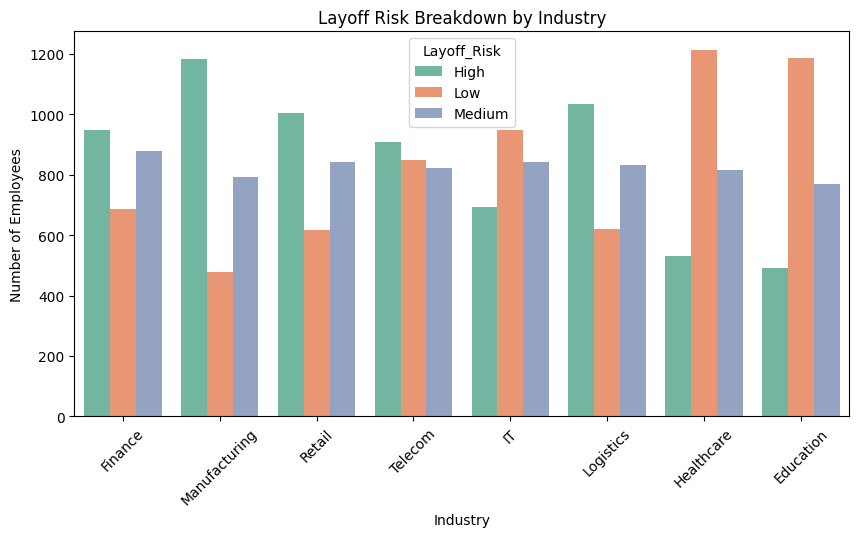

In [ ]:
plt.figure(figsize=(10, 5))
# A countplot grouped by Layoff Risk
sns.countplot(x='Industry', hue='Layoff_Risk', data=df, palette='Set2')

plt.title('Layoff Risk Breakdown by Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45) # Tilts the text so it's easy to read
plt.show()

/tmp/ipykernel_22658/3971171479.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Layoff_Risk', y='Years_of_Experience', data=df, palette='coolwarm')


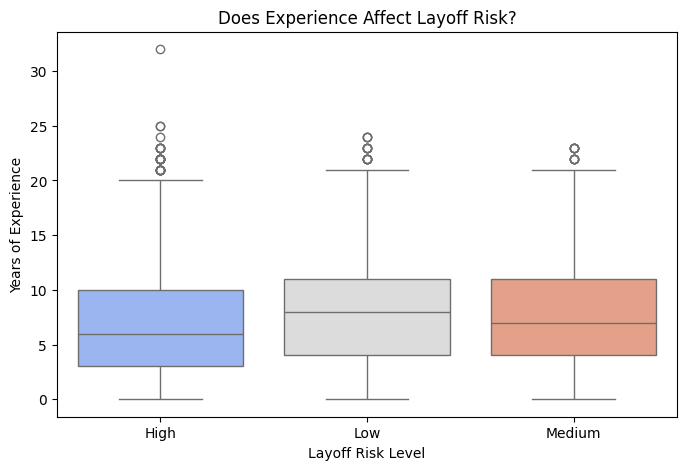

In [ ]:
plt.figure(figsize=(8, 5))
# Boxplot comparing a category (Risk) vs a number (Experience)
sns.boxplot(x='Layoff_Risk', y='Years_of_Experience', data=df, palette='coolwarm')

plt.title('Does Experience Affect Layoff Risk?')
plt.xlabel('Layoff Risk Level')
plt.ylabel('Years of Experience')
plt.show()

In [ ]:
# 1. Calculate the bounds for what is considered "normal"
Q1 = df['Years_of_Experience'].quantile(0.25)
Q3 = df['Years_of_Experience'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Keep only the rows where the experience is inside the normal bounds
df = df[(df['Years_of_Experience'] >= lower_bound) & (df['Years_of_Experience'] <= upper_bound)]

# Now if you plot your boxplot again, the crazy extremes will be permanently gone!

/tmp/ipykernel_22658/3971171479.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Layoff_Risk', y='Years_of_Experience', data=df, palette='coolwarm')


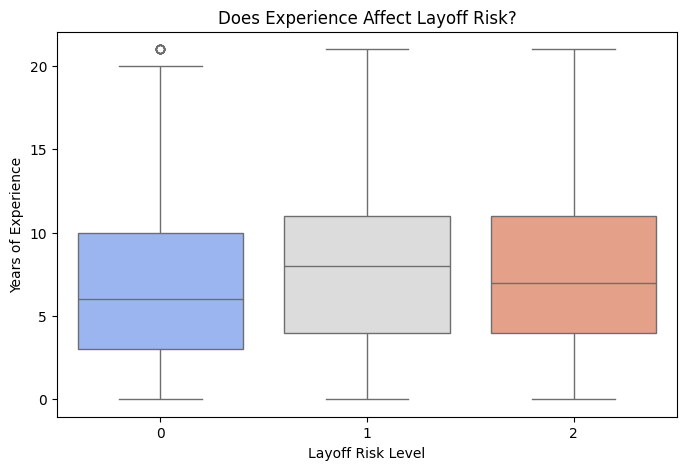

In [ ]:
plt.figure(figsize=(8, 5))
# Boxplot comparing a category (Risk) vs a number (Experience)
sns.boxplot(x='Layoff_Risk', y='Years_of_Experience', data=df, palette='coolwarm')

plt.title('Does Experience Affect Layoff Risk?')
plt.xlabel('Layoff Risk Level')
plt.ylabel('Years of Experience')
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder



# Convert target to numbers (0, 1, 2)
le = LabelEncoder()
df['Layoff_Risk'] = le.fit_transform(df['Layoff_Risk'])

# Convert remaining text columns to dummy variables (1s and 0s)
df = pd.get_dummies(df, drop_first=True)
print(df.columns)
df.shape

Index(['Age', 'Years_of_Experience', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week',
       'Tasks_Automated_Percentage', 'AI_Training_Hours', 'Layoff_Risk',
       'Education_Level_High School', 'Education_Level_Master's',
       'Education_Level_PhD', 'Industry_Finance', 'Industry_Healthcare',
       'Industry_IT', 'Industry_Logistics', 'Industry_Manufacturing',
       'Industry_Retail', 'Industry_Telecom', 'Job_Role_Accountant',
       'Job_Role_Auditor', 'Job_Role_Data Analyst', 'Job_Role_Dispatcher',
       'Job_Role_Financial Analyst', 'Job_Role_Health Analyst',
       'Job_Role_Inventory Analyst', 'Job_Role_ML Engineer',
       'Job_Role_Medical Assistant', 'Job_Role_Network Engineer',
       'Job_Role_Nurse', 'Job_Role_Operations Analyst', 'Job_Role_Operator',
       'Job_Role_Production Supervisor', 'Job_Role_Quality Engineer',
       'Job_Role_Research Assistant', 'Job_Role_Sal

(19954, 49)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Layoff_Risk', axis=1)
y = df['Layoff_Risk']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred1 = log_reg.predict(X_test)
acc1 = accuracy_score(y_test, y_pred1)

print("Logistic Regression Accuracy:", round(acc1, 4))

Logistic Regression Accuracy: 0.9401


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred2 = rf.predict(X_test)
acc2 = accuracy_score(y_test, y_pred2)

print("Random Forest Accuracy:", round(acc2, 4))

Random Forest Accuracy: 0.8745


In [ ]:
if acc1 > acc2:
    print("Best Model: Logistic Regression")
elif acc2 > acc1:
    print("Best Model: Random Forest")
else:
    print("Both models performed equally well.")

Best Model: Logistic Regression


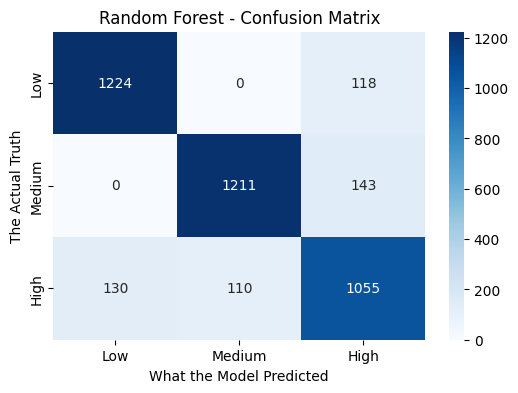

In [ ]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the Random Forest predictions
cm = confusion_matrix(y_test, y_pred2)

# Plot it using Seaborn (sns)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('What the Model Predicted')
plt.ylabel('The Actual Truth')
plt.show()

/tmp/ipykernel_22658/1517002086.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')


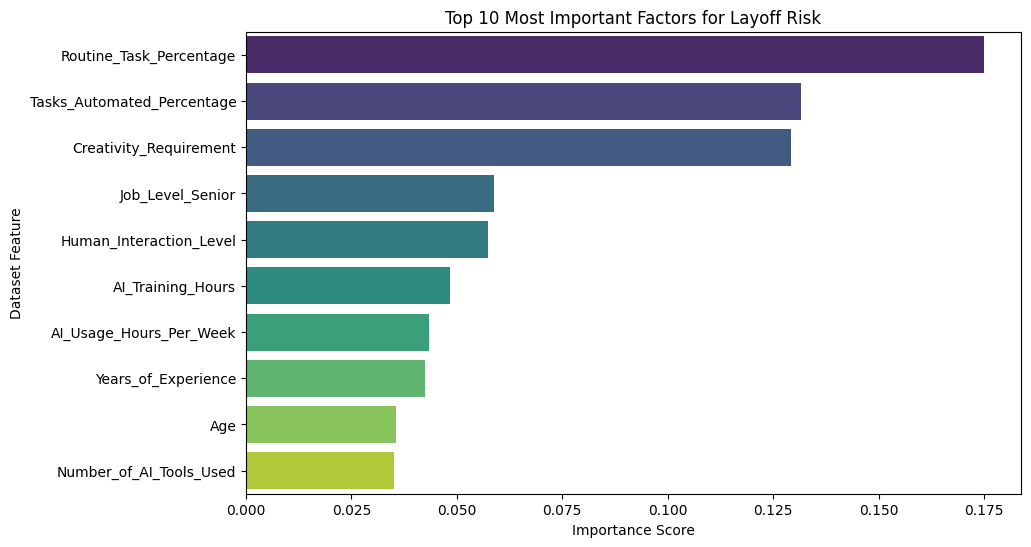

In [ ]:
# Get the importance of each feature from the Random Forest model
importances = rf.feature_importances_

# Create a dataframe to easily plot it
feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')

plt.title('Top 10 Most Important Factors for Layoff Risk')
plt.xlabel('Importance Score')
plt.ylabel('Dataset Feature')
plt.show()